In [7]:
import math
import numpy as np
from tqdm import tqdm
import re

def load_config(filename):
    params = {}
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            key, value = re.split(r"\s*=\s*", line)
            try:
                if "." in value or "e" in value.lower():
                    params[key] = float(value)
                else:
                    params[key] = int(value)
            except ValueError:
                params[key] = value
    return params

# Load parameters
config = load_config("config.txt")
Nx = int(config["Nx"]); Ny = int(config["Ny"]); Nz = int(config["Nz"])
Deltaxy = float(config["Deltaxy"]); DeltaZ = float(config["DeltaZ"])
ROIRadius = float(config["ROIRadius"]); FirstSliceNumber = int(config["FirstSliceNumber"])
NViews = int(config["NViews"]); NChan = int(config["NChan"])
DeltaCh = float(config["DeltaCh"]); CenterOff = float(config["CenterOff"])
DeltaSlice = float(config["DeltaSlice"])
LEN_PIX = int(config["LEN_PIX"]); BIN = int(config["BIN"]) #bin is detector bin cluster
OUT_A = "/content/A_parallel_params.npz"

print("Loaded parameters:")
for k, v in config.items():
    print(f"  {k} = {v}")

def make_angles(n, dtype=np.float32):
    step = math.pi / n
    return np.array([i * step for i in range(n)], dtype=dtype)

def pixel_center(j, Nx, Ny, dxy):
    jx = j % Nx
    jy = j // Nx
    x = (jx - (Nx - 1) / 2.0) * dxy
    y = (jy - (Ny - 1) / 2.0) * dxy
    return x, y

def det_centers(N, dch, off_bins, dtype=np.float32):
    idx = np.arange(N, dtype=dtype)
    return (idx - (N - 1) / 2.0 - off_bins) * dch

def build_pixel_profiles(angles, DeltaPix, LEN_PIX, dtype=np.float32):
    pi = math.pi
    rc = math.sin(pi / 4.0)
    P = np.zeros((angles.size, LEN_PIX), dtype=dtype)
    for vi in range(angles.size):
        ang = float(angles[vi])
        while ang >= pi / 2.0:
            ang -= pi / 2.0
        while ang < 0.0:
            ang += pi / 2.0
        if ang <= pi / 4.0:
            maxval = DeltaPix / max(math.cos(ang), 1e-12)
        else:
            maxval = DeltaPix / max(math.cos(pi / 2.0 - ang), 1e-12)
        d1 = rc * math.cos(pi / 4.0 - ang)
        d2 = rc * abs(math.sin(pi / 4.0 - ang))
        t1 = 1.0 - d1
        t2 = 1.0 - d2
        t3 = 1.0 + d2
        t4 = 1.0 + d1
        for uj in range(LEN_PIX):
            t = 2.0 * uj / float(LEN_PIX)
            if (t <= t1) or (t > t4):
                val = 0.0
            elif t <= t2:
                denom = (t2 - t1) if (t2 - t1) != 0.0 else 1e-12
                val = maxval * (t - t1) / denom
            elif t <= t3:
                val = maxval
            else:
                denom = (t4 - t3) if (t4 - t3) != 0.0 else 1e-12
                val = maxval * (t4 - t) / denom
            P[vi, uj] = val
    return P

def channel_window(x, y, theta, DeltaPix, t0, DeltaCh, NChan):
    s0 = y * math.cos(theta) - x * math.sin(theta)
    t_min = s0 - DeltaPix
    t_max = s0 + DeltaPix
    i_min = math.ceil((t_min - t0) / DeltaCh - 0.5)
    i_max = math.floor((t_max - t0) / DeltaCh + 0.5)
    i_min = max(i_min, 0)
    i_max = min(i_max, NChan - 1)
    return i_min, i_max, s0

def profile_index(t_i, s0, DeltaPix, LEN_PIX):
    u_float = ((t_i - s0) + DeltaPix) * (LEN_PIX - 1) / (2.0 * DeltaPix)
    u = int(math.floor(u_float + 0.5))
    if u < 0:
        return 0
    if u >= LEN_PIX:
        return LEN_PIX - 1
    return u

def build_column(j, Nx, Ny, Deltaxy, angles, tcent, DeltaCh, LEN_PIX, P):
    NViews = angles.size
    NChan  = tcent.size
    DeltaPix = Deltaxy
    t0 = float(tcent[0])
    x, y = pixel_center(j, Nx, Ny, Deltaxy)
    rows, vals = [], []
    for p in range(NViews):
        theta = float(angles[p])
        i_min, i_max, s0 = channel_window(x, y, theta, DeltaPix, t0, DeltaCh, NChan)
        if i_min > i_max:
            continue
        for i in range(i_min, i_max + 1):
            u = profile_index(float(tcent[i]), s0, DeltaPix, LEN_PIX)
            w = float(P[p, u])
            if w > 0.0:
                rows.append(p * NChan + i)
                vals.append(w)
    return rows, vals

def main():
    if NChan % BIN != 0:
        raise ValueError(f"NChan ({NChan}) must be divisible by BIN ({BIN}).")
    nchan = NChan // BIN
    dch   = DeltaCh * BIN
    coff  = CenterOff / BIN

    angles = make_angles(NViews, dtype=np.float32)
    tcent  = det_centers(nchan, dch, coff, dtype=np.float32)
    P      = build_pixel_profiles(angles, Deltaxy, LEN_PIX, dtype=np.float32)

    Nrows = NViews * nchan
    Ncols = Nx * Ny
    r_all, c_all, v_all = [], [], []

    for j in tqdm(range(Ncols), desc="Building A", unit="col"):
        rj, vj = build_column(j, Nx, Ny, Deltaxy, angles, tcent, dch, LEN_PIX, P)
        if rj:
            r_all.extend(rj)
            c_all.extend([j] * len(rj))
            v_all.extend(vj)

    r_all = np.asarray(r_all, dtype=np.int64)
    c_all = np.asarray(c_all, dtype=np.int64)
    v_all = np.asarray(v_all, dtype=np.float32)

    a_matrix = {
        "row_idx_all": r_all,
        "col_idx_all": c_all,
        "val_all": v_all,
        "Nrows": np.int64(Nrows),
        "Ncols": np.int64(Ncols),
        "Nx": np.int64(Nx),
        "Ny": np.int64(Ny),
        "Nz": np.int64(Nz),
        "Deltaxy": np.float64(Deltaxy),
        "LEN_PIX": np.int64(LEN_PIX),
        "NViews": np.int64(NViews),
        "NChannels": np.int64(nchan),
        "DeltaChannel": np.float64(dch),
        "CenterOffset": np.float64(coff),
        "DeltaSlice": np.float64(DeltaSlice),
        "BIN": np.int64(BIN),
    }

    np.savez_compressed(OUT_A, **a_matrix)
    print(f"saved {OUT_A} | rows={Nrows} cols={Ncols} nnz={r_all.size}")

if __name__ == "__main__":
    main()


Loaded parameters:
  Nx = 128
  Ny = 128
  Nz = 1
  Deltaxy = 0.0005
  DeltaZ = 6.25e-05
  ROIRadius = 0.032
  FirstSliceNumber = 700
  NViews = 225
  NChan = 1024
  DeltaCh = 6.25e-05
  CenterOff = 23.0
  DeltaSlice = 6.25e-05
  LEN_PIX = 511
  BIN = 1


Building A: 100%|██████████| 16384/16384 [01:11<00:00, 229.71col/s]


saved /content/A_parallel_params.npz | rows=230400 cols=16384 nnz=35226503


dev: cpu
A: grid=(128,128,1) views=225 det=1024 nnz=35226503
sino: (225, 1, 1024) min/max: -0.11988259851932526 0.7530611753463745
||y||2: 158.57373046875 ||Ax0||2: 0.0
  25  L=1.919e+06  F=1.919e+06  QGGMRF=0.000e+00  lr=0.3
  50  L=3.572e+05  F=3.572e+05  QGGMRF=0.000e+00  lr=0.3
  75  L=2.734e+05  F=2.734e+05  QGGMRF=0.000e+00  lr=0.3
 100  L=2.541e+05  F=2.541e+05  QGGMRF=0.000e+00  lr=0.3
 125  L=2.507e+05  F=2.507e+05  QGGMRF=0.000e+00  lr=0.3
 150  L=2.500e+05  F=2.500e+05  QGGMRF=0.000e+00  lr=0.06
 175  L=2.500e+05  F=2.500e+05  QGGMRF=0.000e+00  lr=0.06
 200  L=2.499e+05  F=2.499e+05  QGGMRF=0.000e+00  lr=0.06
saved: /content/mbir_reconstruction.npy


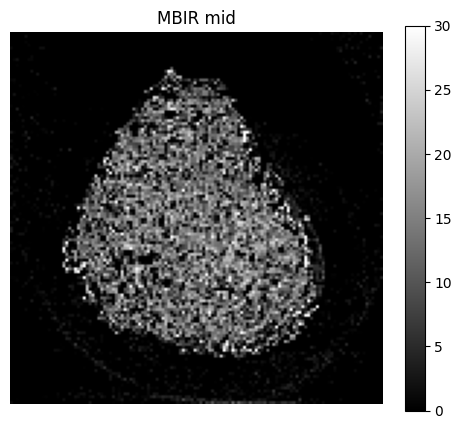

In [8]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# paths
A_PATH   = "A_parallel_params.npz"
SINO_PATH= "xradia_slice0700.2Dsinodata"
W_PATH   = "xradia_slice0700.2Dweightdata"
# dev
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available(): torch.cuda.set_device(0)
print("dev:", device)

# load A
A = np.load(A_PATH)
row_idx = torch.tensor(A["row_idx_all"], dtype=torch.long, device=device)
col_idx = torch.tensor(A["col_idx_all"], dtype=torch.long, device=device)
aval    = torch.tensor(A["val_all"],     dtype=torch.float32, device=device)
Nx, Ny, Nz = int(A["Nx"]), int(A["Ny"]), int(A.get("Nz", 1))
V, C       = int(A["NViews"]), int(A["NChannels"])
print(f"A: grid=({Nx},{Ny},{Nz}) views={V} det={C} nnz={row_idx.numel()}")

# load sino
with open(SINO_PATH, "rb") as f:
    flat = np.frombuffer(f.read(), dtype=np.float32)
if flat.size not in (V*C, V*1*C):
    raise ValueError(f"bad size {flat.size}, want {V*C}")
s2d = flat.reshape(V, 1, C).astype(np.float32)
if Nz > 1:
    sino = np.zeros((V, Nz, C), dtype=np.float32)
    midz = Nz // 2
    sino[:, midz:midz+1, :] = s2d
else:
    sino = s2d
y = torch.tensor(sino, dtype=torch.float32, device=device)
print("sino:", tuple(y.shape), "min/max:", y.min().item(), y.max().item())

# projector
def proj_mid(xflat, recon_shape):
    Vloc, Nzloc, Cloc = V, recon_shape[2], C
    ncols = recon_shape[0]*recon_shape[1]
    if xflat.dim()==1: X = xflat.view(ncols, 1)
    else:              X = xflat
    ypred = torch.zeros((Vloc, Nzloc, Cloc), dtype=torch.float32, device=device)
    mid = Nzloc//2
    xmid = X[:, mid]
    yz = torch.zeros(Vloc*Cloc, dtype=torch.float32, device=device)
    yz.index_add_(0, row_idx, aval * xmid[col_idx])
    ypred[:, mid, :] = yz.view(Vloc, Cloc)
    return ypred

# weight
with open(W_PATH, "rb") as f:
    wflat = np.frombuffer(f.read(), dtype=np.float32)
w = torch.tensor(wflat.reshape(V, 1, C), dtype=torch.float32, device=device)
if Nz > 1:
    w3d = torch.zeros((V, Nz, C), dtype=torch.float32, device=device)
    midz = Nz // 2
    w3d[:, midz:midz+1, :] = w
    w = w3d
w_sqrt = torch.sqrt(torch.clamp(w, min=0.0))

# ----------------- QGGMRF (drop-in) -----------------
# This replaces the old tv_mid. Same API, acts on the mid-slice.
def qggmrf_mid(x, sigma_x=1, p=1.2, q=2.0, T=0.015, beta=1.0):
    """
    QGGMRF prior on the mid-slice.
    Returns a scalar 'energy placeholder' whose backward() applies the correct QGGMRF gradient.
    Keep your training loop & loss_fn unchanged. Tune via LAM.
    """
    class _QGGMRFApply(torch.autograd.Function):
        @staticmethod
        def forward(ctx, s, sigma_x, p, q, T, beta):
            ctx.save_for_backward(s)
            ctx.sigma_x, ctx.p, ctx.q, ctx.T, ctx.beta = sigma_x, p, q, T, beta
            # Value placeholder (we inject correct gradient in backward).
            return s.new_tensor(0.0)

        @staticmethod
        def backward(ctx, grad_output):
            (s,) = ctx.saved_tensors
            sigma_x, p, q, T, beta = ctx.sigma_x, ctx.p, ctx.q, ctx.T, ctx.beta
            with torch.no_grad():
                tiny = 1e-12

                # Forward differences creating edge signals (8-neighbors)
                diff_x  = torch.zeros_like(s); diff_x[:, :-1]  = s[:, :-1]  - s[:,  1:]   # left - right
                diff_y  = torch.zeros_like(s); diff_y[:-1, :]  = s[:-1, :]  - s[1:,  :]   # up   - down
                diff_d1 = torch.zeros_like(s); diff_d1[:-1, :-1] = s[:-1, :-1] - s[1:, 1:]   # TL - BR
                diff_d2 = torch.zeros_like(s); diff_d2[:-1,  1:] = s[:-1,  1:] - s[1:, :-1]  # TR - BL

                def influence(d):
                    ad = d.abs()
                    r = torch.zeros_like(ad)
                    mask = ad > 0
                    r[mask] = (ad[mask] / (T * sigma_x + tiny)).pow(q - p)
                    leading = torch.zeros_like(ad)
                    leading[mask] = ad[mask].pow(p - 1) / (sigma_x ** p + tiny)
                    bracket = r * (q / p + r) / (1.0 + r).pow(2.0)
                    psi = leading * bracket * d.sign()
                    return psi

                g = torch.zeros_like(s)

                # Horizontal
                psi = influence(diff_x)
                g[:, :-1] += beta * psi[:, :-1]
                g[:,  1:] -= beta * psi[:, :-1]

                # Vertical
                psi = influence(diff_y)
                g[:-1, :] += beta * psi[:-1, :]
                g[ 1:, :] -= beta * psi[:-1, :]

                # Diagonal TL->BR
                psi = influence(diff_d1)
                g[:-1, :-1] += beta * psi[:-1, :-1]
                g[ 1:,  1:] -= beta * psi[:-1, :-1]

                # Diagonal TR->BL
                psi = influence(diff_d2)
                g[:-1,  1:] += beta * psi[:-1,  1:]
                g[ 1:, :-1] -= beta * psi[:-1,  1:]

            return grad_output * g, None, None, None, None, None

    z = x.shape[2] // 2
    s = x[:, :, z]  # mid-slice (Nx, Ny)
    return _QGGMRFApply.apply(s, float(sigma_x), float(p), float(q), float(T), float(beta))
# ----------------------------------------------------

# loss
LAM = 0.01  # regularization weight (0 keeps output identical to data-fit only)

def loss_fn(x3d):
    Ax = proj_mid(x3d.view(-1, x3d.shape[2]), x3d.shape)
    mid = x3d.shape[2] // 2
    # weighted residual
    r = (Ax[:, mid:mid+1, :] - y[:, mid:mid+1, :]) * w_sqrt[:, mid:mid+1, :]
    Fterm = torch.sum(r * r)
    QGGMRF = qggmrf_mid(x3d)  # <- replaced tv_mid with qggmrf_mid
    return Fterm + LAM * QGGMRF, Fterm, QGGMRF

# init
x = torch.zeros((Nx, Ny, Nz), dtype=torch.float32, requires_grad=True, device=device)

# opt
opt = torch.optim.Adam([x], lr=0.3)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=150, gamma=0.2)

# sanity
with torch.no_grad():
    Ax0 = proj_mid(x.view(-1, Nz), x.shape)
print("||y||2:", y.norm().item(), "||Ax0||2:", Ax0.norm().item())

# train
ITERS = 200
for it in range(1, ITERS+1):
    opt.zero_grad()
    total, Fterm, QGGMRF = loss_fn(x)
    total.backward()
    torch.nn.utils.clip_grad_norm_([x], 1.0)
    opt.step(); sched.step()
    with torch.no_grad(): x.clamp_(min=0.0)
    if it % 25 == 0:
        print(f"{it:4d}  L={total.item():.3e}  F={Fterm.item():.3e}  QGGMRF={QGGMRF.item():.3e}  lr={sched.get_last_lr()[0]:.3g}")

# save
np.save("mbir_reconstruction.npy", x.detach().cpu().numpy())
print("saved: /content/mbir_reconstruction.npy")

# show
xnp = x.detach().cpu().numpy()
sl = xnp[:,:,Nz//2]
p2,p98 = np.percentile(sl,[2,98])
if p2==p98: p2,p98 = sl.min(), sl.max()
plt.figure(figsize=(6,5))
plt.imshow(sl, cmap="gray", vmin=0, vmax=30); plt.axis("off"); plt.colorbar()
plt.title("MBIR mid"); plt.show()
